# 02 — Data validation

Checks the five raw NASA POWER downloads against expectations before any analysis:
row counts vs. the expected 7,305 days/site (2005-01-01 → 2024-12-31), calendar
continuity, duplicate dates, missing-value sentinels (−999), and physical-range
checks per variable. Produces the dataset previews (screenshots) and the summary
tables required for the *Data Description* section of the interim report, and
mirrors `src/validate_data.py`, which writes `results/data_validation_report.txt`.


In [1]:
import sys, warnings
sys.path.append('../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (SITES, PARAMETERS, START, END, DATA_RAW, DATA_PROCESSED,
                    RESULTS, TRAIN_END, VAL_END)

TARGET = 'ALLSKY_SFC_SW_DWN'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# Sites ordered north -> south; fixed colour per site (Okabe-Ito subset,
# colour-blind-safe; validated for adjacent-pair CVD separation).
SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})


## 2.1 Raw file overview

One CSV per site, produced by `src/download_power.py` (SHA-256 digests in
`data/raw/download_log.txt`).

In [2]:
raw = {}
rows = []
for key, site in SITES.items():
    path = DATA_RAW / f"{key}_power_daily_{START}_{END}.csv"
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime({'year': df['YEAR'], 'month': df['MO'], 'day': df['DY']})
    raw[key] = df
    rows.append({'Site': site['name'], 'Zone': site['zone'], 'File': path.name,
                 'Rows': len(df), 'Columns': df.shape[1],
                 'First date': df['date'].min().date(), 'Last date': df['date'].max().date()})
overview = pd.DataFrame(rows)
overview

,Site,Zone,File,Rows,Columns,First date,Last date
0,Accra,coastal_savannah,accra_power_daily_20050101_20241231.csv,7305,10,2005-01-01,2024-12-31
1,Takoradi,coastal,takoradi_power_daily_20050101_20241231.csv,7305,10,2005-01-01,2024-12-31
2,Kumasi,forest,kumasi_power_daily_20050101_20241231.csv,7305,10,2005-01-01,2024-12-31
3,Tamale,guinea_savannah,tamale_power_daily_20050101_20241231.csv,7305,10,2005-01-01,2024-12-31
4,Navrongo,sudan_savannah,navrongo_power_daily_20050101_20241231.csv,7305,10,2005-01-01,2024-12-31


## 2.2 Dataset preview

First rows of the Accra file — screenshot this table for the interim report's
*Screenshots / Evidence* requirement (all five files share the same layout).

In [3]:
raw['accra'].head(10)

,YEAR,MO,DY,ALLSKY_SFC_SW_DWN,T2M,RH2M,CLOUD_AMT,PRECTOTCORR,WS2M,date
0,2005,1,1,5.2625,26.82,85.64,47.32,5.05,1.76,2005-01-01
1,2005,1,2,5.8656,26.32,71.60,12.33,1.08,2.12,2005-01-02
2,2005,1,3,5.7005,26.75,77.16,1.61,0.01,1.35,2005-01-03
3,2005,1,4,5.8726,27.05,77.45,5.20,0.26,1.37,2005-01-04
4,2005,1,5,4.7381,27.02,83.28,51.57,1.25,1.47,2005-01-05
5,2005,1,6,5.0014,27.00,76.57,41.14,0.58,1.66,2005-01-06
6,2005,1,7,4.6589,25.46,69.32,22.14,0.00,2.21,2005-01-07
7,2005,1,8,3.8582,25.03,60.78,27.20,0.00,3.97,2005-01-08
8,2005,1,9,4.8574,24.46,58.97,7.53,0.00,3.91,2005-01-09
9,2005,1,10,5.1818,25.15,59.15,25.34,0.00,3.24,2005-01-10


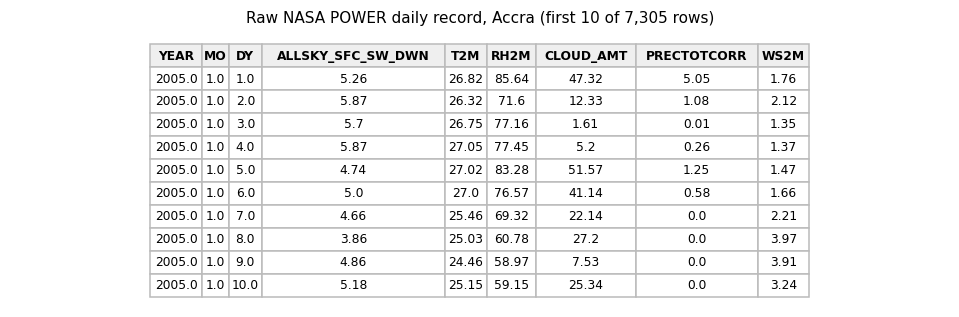

In [4]:
# Save a screenshot-style image of the dataset preview for the interim report
prev = raw['accra'].head(10).copy()
for ic in ['YEAR', 'MO', 'DY']:
    prev[ic] = prev[ic].astype(int)
cols = ['YEAR', 'MO', 'DY'] + PARAMETERS
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.axis('off')
tbl = ax.table(cellText=prev[cols].round(2).values, colLabels=cols,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.25)
tbl.auto_set_column_width(list(range(len(cols))))
for (r, c_), cell in tbl.get_celld().items():
    cell.set_edgecolor('#BBBBBB')
    if r == 0:
        cell.set_text_props(fontweight='bold'); cell.set_facecolor('#EFEFEF')
ax.set_title('Raw NASA POWER daily record, Accra (first 10 of 7,305 rows)', fontsize=10, pad=8)
FIGDIR = RESULTS / 'figures'; FIGDIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGDIR / 'fig_02_1_dataset_preview.png')
plt.show()

## 2.3 Row counts, calendar continuity, duplicates

In [5]:
expected_days = (pd.Timestamp(END) - pd.Timestamp(START)).days + 1
checks = []
for key, site in SITES.items():
    df = raw[key]
    full = pd.date_range(pd.Timestamp(START), pd.Timestamp(END), freq='D')
    missing_dates = full.difference(pd.DatetimeIndex(df['date']))
    checks.append({'Site': site['name'], 'Rows': len(df), 'Expected': expected_days,
                   'Missing dates': len(missing_dates),
                   'Duplicate dates': int(df['date'].duplicated().sum()),
                   'Verdict': 'PASS' if (len(df) == expected_days
                                          and len(missing_dates) == 0
                                          and not df['date'].duplicated().any()) else 'FAIL'})
row_check = pd.DataFrame(checks)
row_check

,Site,Rows,Expected,Missing dates,Duplicate dates,Verdict
0,Accra,7305,7305,0,0,PASS
1,Takoradi,7305,7305,0,0,PASS
2,Kumasi,7305,7305,0,0,PASS
3,Tamale,7305,7305,0,0,PASS
4,Navrongo,7305,7305,0,0,PASS


## 2.4 Missing values (−999 sentinels)

NASA POWER encodes missing observations as −999. Counts and percentages per
site × variable feed the interim report's data-cleaning log.

In [6]:
miss_rows = []
for key, site in SITES.items():
    df = raw[key]
    for p in PARAMETERS:
        col = pd.to_numeric(df[p], errors='coerce')
        n_sentinel = int((col == -999).sum()) + int(col.isna().sum())
        miss_rows.append({'Site': site['name'], 'Variable': p,
                          'Missing (n)': n_sentinel,
                          'Missing (%)': round(100 * n_sentinel / len(df), 3)})
missingness = pd.DataFrame(miss_rows)
missingness.to_csv(RESULTS / 'validation_missingness.csv', index=False)
missingness.pivot(index='Variable', columns='Site', values='Missing (n)')

Site,Accra,Kumasi,Navrongo,Takoradi,Tamale
Variable,,,,,
ALLSKY_SFC_SW_DWN,0,0,0,0,0
CLOUD_AMT,0,0,0,0,0
PRECTOTCORR,0,0,0,0,0
RH2M,0,0,0,0,0
T2M,0,0,0,0,0
WS2M,0,0,0,0,0


## 2.5 Physical-range checks

Each variable must fall inside a physically plausible envelope (same limits as
`src/validate_data.py`).

In [7]:
RANGES = {'ALLSKY_SFC_SW_DWN': (0, 9), 'T2M': (5, 45), 'RH2M': (0, 100),
          'CLOUD_AMT': (0, 100), 'PRECTOTCORR': (0, 400), 'WS2M': (0, 25)}
range_rows = []
for key, site in SITES.items():
    df = raw[key]
    for p in PARAMETERS:
        col = pd.to_numeric(df[p], errors='coerce').replace(-999, np.nan)
        lo, hi = RANGES[p]
        n_out = int(((col < lo) | (col > hi)).sum())
        range_rows.append({'Site': site['name'], 'Variable': p,
                           'Min': round(float(col.min()), 2), 'Max': round(float(col.max()), 2),
                           'Allowed': f'[{lo}, {hi}]', 'Out of range (n)': n_out,
                           'Verdict': 'PASS' if n_out == 0 else 'CHECK'})
ranges = pd.DataFrame(range_rows)
ranges.to_csv(RESULTS / 'validation_ranges.csv', index=False)
ranges

,Site,Variable,Min,Max,Allowed,Out of range (n),Verdict
0,Accra,ALLSKY_SFC_SW_DWN,0.51,7.13,"[0, 9]",0,PASS
1,Accra,T2M,22.53,30.13,"[5, 45]",0,PASS
2,Accra,RH2M,51.04,94.55,"[0, 100]",0,PASS
3,Accra,CLOUD_AMT,0.51,99.95,"[0, 100]",0,PASS
4,Accra,PRECTOTCORR,0.00,110.47,"[0, 400]",0,PASS
5,Accra,WS2M,0.99,4.94,"[0, 25]",0,PASS
6,Takoradi,ALLSKY_SFC_SW_DWN,0.54,7.11,"[0, 9]",0,PASS
7,Takoradi,T2M,22.64,30.75,"[5, 45]",0,PASS
8,Takoradi,RH2M,46.17,94.28,"[0, 100]",0,PASS
9,Takoradi,CLOUD_AMT,2.83,99.86,"[0, 100]",0,PASS


## 2.6 Verdict

In [8]:
all_pass = (row_check['Verdict'].eq('PASS').all()
            and missingness['Missing (n)'].eq(0).all()
            and ranges['Verdict'].eq('PASS').all())
print('Rows/calendar:', 'PASS' if row_check['Verdict'].eq('PASS').all() else 'FAIL')
print('Missing values:', 'PASS (0 missing anywhere)' if missingness['Missing (n)'].eq(0).all() else 'ISSUES')
print('Physical ranges:', 'PASS' if ranges['Verdict'].eq('PASS').all() else 'ISSUES')
print('\nOVERALL:', 'PASS' if all_pass else 'ISSUES FOUND')

Rows/calendar: PASS
Missing values: PASS (0 missing anywhere)
Physical ranges: PASS

OVERALL: PASS


**Interpretation.** All five NASA POWER files pass every check: 7,305 rows per site
covering an unbroken daily calendar from 2005-01-01 to 2024-12-31, no duplicate dates,
**zero −999 sentinels** in any of the six variables, and every value inside its physical
envelope (site-level GHI spans 0.51–7.71 kWh/m²/day). No imputation was required — the
≤3-day gap-interpolation step in `src/clean_data.py` had nothing to fill, so cleaning
reduces to sentinel screening, calendar enforcement, and feature engineering (GHI lags
1–7, 7-/30-day rolling means, day-of-year harmonics, season labels). The tables above
(also saved as `results/validation_missingness.csv` and `results/validation_ranges.csv`)
are the evidence for the interim report's *data-cleaning log* and *data dictionary*,
and the previews in §2.2 satisfy its *Screenshots / Evidence* requirement.